In [2]:
#pandas for data understanding
import pandas as pd 

#load the dataset
df = pd.read_csv('../data/UrbanFlow_ML_Full_Dataset.csv')

#display first and last records
print(" --- first 5 rows ---")
display(df.head())

print(" --- last 5 rows ---")
display(df.tail())

#dataset shape and column name
print(f"\n Dataset shapes: {df.shape}")
print(f"\n Columns: {df.columns.tolist()}")

#datatype info (types)
print(" --- Data Information ---")
df.info()

 --- first 5 rows ---


,Bus_ID,Route_Name,Distance_km,Traffic_Density,Weather,Is_Peak_Hour,Actual_Travel_Time,Is_Late
0,SRT-B-0001,Connaught Place to Karol Bagh (Delhi),3.62,8.0,Cloudy,0,44.07,0
1,SRT-B-0002,Andheri East to Andheri West (Mumbai),1.74,8.0,Sunny,0,37.80,0
2,SRT-B-0003,Salt Lake to Esplanade (Kolkata),6.00,5.0,Foggy,1,174.00,1
3,SRT-B-0004,MG Road to Whitefield (Bengaluru),2.23,5.0,Cloudy,1,37.43,0
4,SRT-B-0005,T Nagar to Velachery (Chennai),0.46,NaN,Sunny,1,47.53,0


 --- last 5 rows ---


,Bus_ID,Route_Name,Distance_km,Traffic_Density,Weather,Is_Peak_Hour,Actual_Travel_Time,Is_Late
2995,SRT-B-2996,Shivaji Nagar to Hinjewadi (Pune),6.86,10.0,Rainy,0,74.87,1
2996,SRT-B-2997,Navrangpura to Maninagar (Ahmedabad),6.92,6.0,Rainy,1,69.07,1
2997,SRT-B-2998,Alambagh to Charbagh (Lucknow),1.15,1.0,Sunny,1,17.83,0
2998,SRT-B-2999,Patna Junction to Kankarbagh (Patna),8.42,6.0,Sunny,0,52.07,0
2999,SRT-B-3000,Sector 17 to Mohali (Chandigarh),1.56,4.0,Cloudy,1,31.20,0



 Dataset shapes: (3000, 8)

 Columns: ['Bus_ID', 'Route_Name', 'Distance_km', 'Traffic_Density', 'Weather', 'Is_Peak_Hour', 'Actual_Travel_Time', 'Is_Late']
 --- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Bus_ID              3000 non-null   object 
 1   Route_Name          3000 non-null   object 
 2   Distance_km         2820 non-null   float64
 3   Traffic_Density     2820 non-null   float64
 4   Weather             2820 non-null   object 
 5   Is_Peak_Hour        3000 non-null   int64  
 6   Actual_Travel_Time  3000 non-null   float64
 7   Is_Late             3000 non-null   int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 187.6+ KB


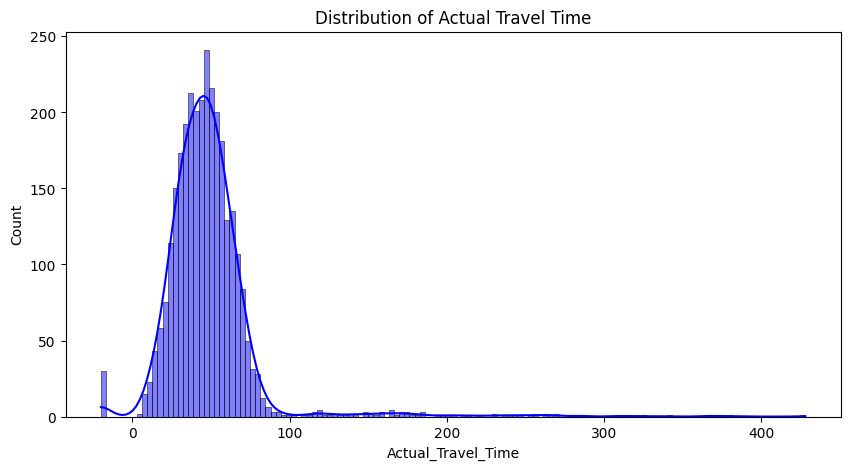

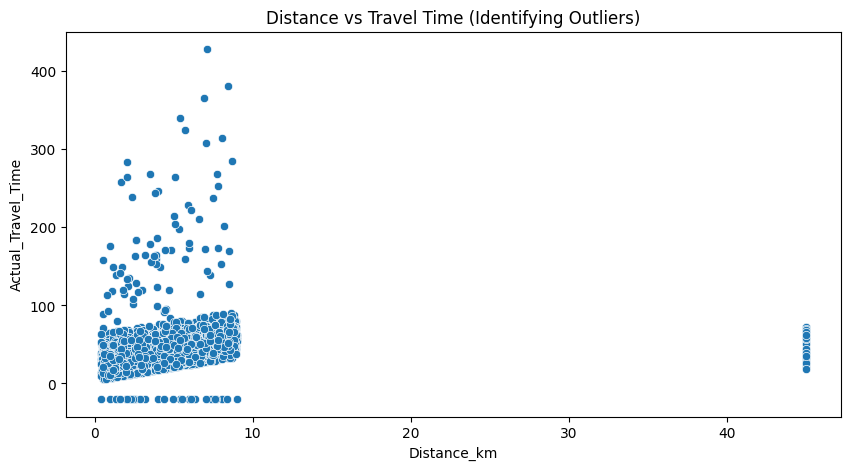

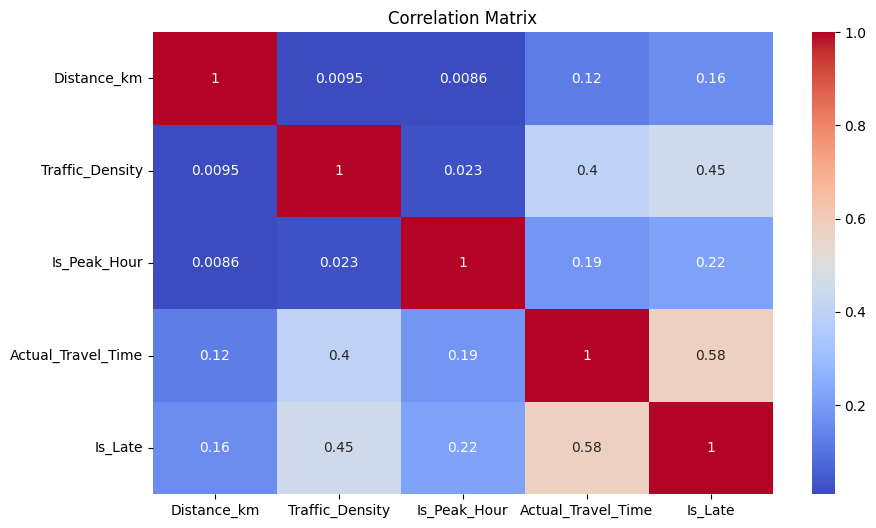

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load the dataset
df = pd.read_csv('../data/UrbanFlow_ML_Full_Dataset.csv')

# Univariate Analysis: Travel Time ka distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Actual_Travel_Time'], kde=True, color='blue') # [cite: 66, 186]
plt.title('Distribution of Actual Travel Time')
plt.show()

# Bivariate Analysis: Distance vs Travel Time
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Distance_km'], y=df['Actual_Travel_Time']) # [cite: 74, 187]
plt.title('Distance vs Travel Time (Identifying Outliers)')
plt.show()

# Multivariate Analysis: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm') # [cite: 80, 113, 188]
plt.title('Correlation Matrix')
plt.show()

--- Missing Values Before Cleaning ---
Bus_ID                  0
Route_Name              0
Distance_km           180
Traffic_Density       180
Weather               180
Is_Peak_Hour            0
Actual_Travel_Time      0
Is_Late                 0
dtype: int64

--- Data Spread (Task 4) ---
        Distance_km  Actual_Travel_Time
mean       5.049927           45.717022
median     4.710000           45.500000
std        4.656832           15.917001
skew       6.253323            0.017012

--- Missing Values After Cleaning ---
Bus_ID                0
Route_Name            0
Distance_km           0
Traffic_Density       0
Weather               0
Is_Peak_Hour          0
Actual_Travel_Time    0
Is_Late               0
dtype: int64
--- Missing Values Before Cleaning ---
Bus_ID                  0
Route_Name              0
Distance_km           180
Traffic_Density       180
Weather               180
Is_Peak_Hour            0
Actual_Travel_Time      0
Is_Late                 0
dtype: int64

--- D

,Distance_km,Traffic_Density,Is_Peak_Hour,Actual_Travel_Time,Is_Late
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,5.049927,5.587667,0.392667,45.717022,0.197667
std,4.656832,2.790623,0.488425,15.917001,0.398306
min,0.400000,1.000000,0.000000,5.730000,0.000000
25%,2.660000,3.000000,0.000000,34.000000,0.000000
50%,4.710000,6.000000,0.000000,45.500000,0.000000
75%,6.642500,8.000000,1.000000,57.130000,0.000000
max,45.000000,10.000000,1.000000,75.633500,1.000000



--- 4. Correlation Matrix ---


,Distance_km,Traffic_Density,Is_Peak_Hour,Actual_Travel_Time,Is_Late
Distance_km,1.000000,0.008466,0.008275,0.222716,0.156017
Traffic_Density,0.008466,1.000000,0.023174,0.666145,0.439638
Is_Peak_Hour,0.008275,0.023174,1.000000,0.308381,0.221360
Actual_Travel_Time,0.222716,0.666145,0.308381,1.000000,0.716633
Is_Late,0.156017,0.439638,0.221360,0.716633,1.000000


--- Covariance Matrix ---


,Distance_km,Traffic_Density,Is_Peak_Hour,Actual_Travel_Time
Distance_km,21.686088,0.110023,0.018822,16.508354
Traffic_Density,0.110023,7.787577,0.031587,29.589047
Is_Peak_Hour,0.018822,0.031587,0.238559,2.397436
Actual_Travel_Time,16.508354,29.589047,2.397436,253.350909



--- Correlation Matrix ---


,Distance_km,Traffic_Density,Is_Peak_Hour,Actual_Travel_Time
Distance_km,1.000000,0.008466,0.008275,0.222716
Traffic_Density,0.008466,1.000000,0.023174,0.666145
Is_Peak_Hour,0.008275,0.023174,1.000000,0.308381
Actual_Travel_Time,0.222716,0.666145,0.308381,1.000000


Model Training Complete!
Features used for training: ['Distance_km', 'Traffic_Density', 'Is_Peak_Hour', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Sunny']

--- Simple Linear Regression Evaluation ---
Mean Squared Error (MSE): 240.39
R2 Score: 0.0521

--- Multiple Linear Regression Evaluation ---
Mean Squared Error (MSE): 100.51
R2 Score: 0.6037

--- Decision Tree Regressor Evaluation ---
Mean Squared Error (MSE): 86.89
R2 Score: 0.6574

--- Logistic Regression (Classification) ---
Accuracy: 0.85
Confusion Matrix:
[[445  40]
 [ 51  64]]


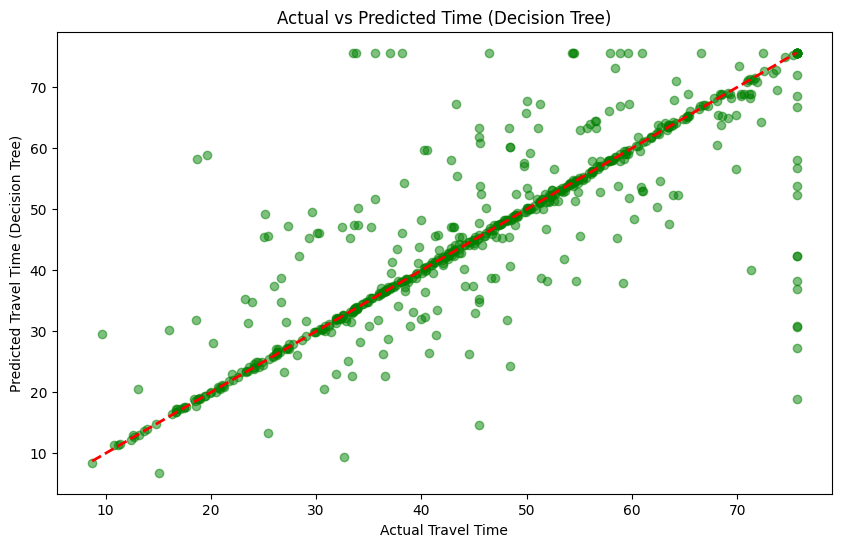

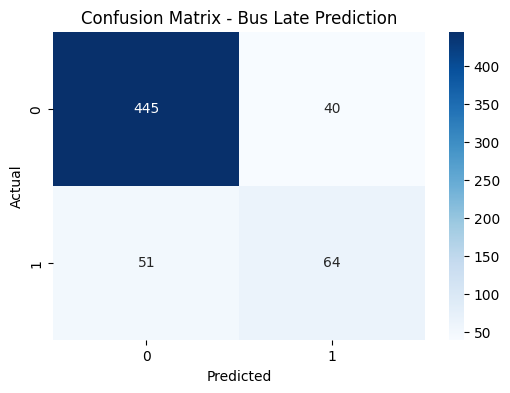

Model and Columns exported successfully to backend folder!
Model exported successfully!


In [8]:
# Task 3 & 4: Handling Missing Data, Outliers and Data Spread
import pandas as pd

#load the dataset
df = pd.read_csv('../data/UrbanFlow_ML_Full_Dataset.csv')

# 1. Missing Values check karna
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# Topper Logic: Traffic_Density ke liye 'Mode' (sabse zyada baar aane wala number) 
# aur Distance ke liye 'Median' use karenge kyunki Distance mein outliers ho sakte hain.
df['Traffic_Density'] = df['Traffic_Density'].fillna(df['Traffic_Density'].mode()[0])
df['Distance_km'] = df['Distance_km'].fillna(df['Distance_km'].median())
df['Weather'] = df['Weather'].fillna('Sunny') # Categorical ke liye simple fill

# 2. Outliers Handling (Task 3)
# Actual_Travel_Time mein -20 impossible hai, hum use 0 se replace karenge ya median se.
df.loc[df['Actual_Travel_Time'] < 0, 'Actual_Travel_Time'] = df['Actual_Travel_Time'].median()

# Extreme Outliers (999 mins) ko hum 95th percentile se cap kar denge (Topper technique)
upper_limit = df['Actual_Travel_Time'].quantile(0.95)
df.loc[df['Actual_Travel_Time'] > upper_limit, 'Actual_Travel_Time'] = upper_limit

# 3. Spread of Data (Task 4)
print("\n--- Data Spread (Task 4) ---")
stats = df[['Distance_km', 'Actual_Travel_Time']].agg(['mean', 'median', 'std', 'skew'])
print(stats)

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())





# Task 3 & 4: Handling Missing Data, Outliers and Data Spread
import pandas as pd

#load the dataset
df = pd.read_csv('../data/UrbanFlow_ML_Full_Dataset.csv')

# 1. Missing Values check karna
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# Topper Logic: Traffic_Density ke liye 'Mode' (sabse zyada baar aane wala number) 
# aur Distance ke liye 'Median' use karenge kyunki Distance mein outliers ho sakte hain.
df['Traffic_Density'] = df['Traffic_Density'].fillna(df['Traffic_Density'].mode()[0])
df['Distance_km'] = df['Distance_km'].fillna(df['Distance_km'].median())
df['Weather'] = df['Weather'].fillna('Sunny') # Categorical ke liye simple fill

# 2. Outliers Handling (Task 3)
# Actual_Travel_Time mein -20 impossible hai, hum use 0 se replace karenge ya median se.
df.loc[df['Actual_Travel_Time'] < 0, 'Actual_Travel_Time'] = df['Actual_Travel_Time'].median()

# Extreme Outliers (999 mins) ko hum 95th percentile se cap kar denge (Topper technique)
upper_limit = df['Actual_Travel_Time'].quantile(0.95)
df.loc[df['Actual_Travel_Time'] > upper_limit, 'Actual_Travel_Time'] = upper_limit

# 3. Spread of Data (Task 4)
print("\n--- Data Spread (Task 4) ---")
stats = df[['Distance_km', 'Actual_Travel_Time']].agg(['mean', 'median', 'std', 'skew'])
print(stats)

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

# Task 5: Reusable Function for Automation
def get_data_summary(data):
    print("--- 1. Quick Info ---")
    print(data.info())
    
    print("\n--- 2. Missing Values Count ---")
    print(data.isnull().sum())
    
    print("\n--- 3. Numerical Summary ---")
    display(data.describe())
    
    print("\n--- 4. Correlation Matrix ---")
    # Sirf numbers ka correlation nikalne ke liye
    numeric_df = data.select_dtypes(include=['float64', 'int64'])
    display(numeric_df.corr())

# Function ko call karo
get_data_summary(df)





# Task 6: Regression Analysis (Covariance and Correlation)

# 1. Sirf numerical columns select karo (Task 6 ke liye)
regression_data = df[['Distance_km', 'Traffic_Density', 'Is_Peak_Hour', 'Actual_Travel_Time']]

# 2. Calculate Covariance Matrix
print("--- Covariance Matrix ---")
display(regression_data.cov())

# 3. Calculate Correlation Matrix
print("\n--- Correlation Matrix ---")
display(regression_data.corr())





# Task 7 & 8: Data Preprocessing and Model Training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. Encoding: Weather (Categorical) ko numbers mein convert karna
# Isse 'Weather_Rainy', 'Weather_Sunny' jaise naye columns ban jayenge
df_final = pd.get_dummies(df, columns=['Weather'], drop_first=True)

# 2. Features (X) aur Target (y) select karna
# Hum Bus_ID aur Route_Name ko drop kar denge kyunki wo numbers nahi hain
X = df_final.drop(['Bus_ID', 'Route_Name', 'Actual_Travel_Time', 'Is_Late'], axis=1)
y = df_final['Actual_Travel_Time']

# 3. Task 7: Split Dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Task 8: Build and Train Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Complete!")
print(f"Features used for training: {list(X.columns)}")



from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# --- 1. Simple Linear Regression (Task 8-i) ---
# Sirf Distance use karenge
X_simple_train = X_train[['Distance_km']]
X_simple_test = X_test[['Distance_km']]
simple_model = LinearRegression()
simple_model.fit(X_simple_train, y_train)
y_pred_simple = simple_model.predict(X_simple_test)

# --- 2. Decision Tree Regressor (The "Hatke" Algorithm) ---
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# --- 3. Logistic Regression (Task 10: Classification) ---
# Target variable y_late (Is_Late) hoga
y_late_train = df_final.loc[X_train.index, 'Is_Late']
y_late_test = df_final.loc[X_test.index, 'Is_Late']

log_model = LogisticRegression()
log_model.fit(X_train, y_late_train)
y_pred_late = log_model.predict(X_test)

# --- Task 11 & 12: Model Evaluation & Comparison ---
def evaluate(name, y_true, y_pred):
    print(f"\n--- {name} Evaluation ---")
    print(f"Mean Squared Error (MSE): {mean_squared_error(y_true, y_pred):.2f}") # [cite: 165, 175]
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}") # [cite: 170, 179]

# Regression Comparison
evaluate("Simple Linear Regression", y_test, y_pred_simple)
evaluate("Multiple Linear Regression", y_test, model.predict(X_test)) # Pehle wala model
evaluate("Decision Tree Regressor", y_test, y_pred_dt)

# Classification Evaluation (Task 10)
print("\n--- Logistic Regression (Classification) ---")
print(f"Accuracy: {accuracy_score(y_late_test, y_pred_late):.2f}") # [cite: 158]
print("Confusion Matrix:")
print(confusion_matrix(y_late_test, y_pred_late)) #






import matplotlib.pyplot as plt
import seaborn as sns

# 1. Actual vs Predicted (Task 13)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='green') # [cite: 187]
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Travel Time')
plt.ylabel('Predicted Travel Time (Decision Tree)')
plt.title('Actual vs Predicted Time (Decision Tree)')
plt.show()

# 2. Confusion Matrix Visualization (Task 10/13)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_late_test, y_pred_late), annot=True, fmt='d', cmap='Blues') # [cite: 162]
plt.title('Confusion Matrix - Bus Late Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()





import joblib

# 1. Save the model
joblib.dump(dt_model, '../backend/urbanflow_model.pkl')

# 2. Save the column names (Features) 
# Ye zaroori hai taaki backend ko pata chale kaunsa data kis order mein dena hai
model_columns = list(X.columns)
joblib.dump(model_columns, '../backend/model_columns.pkl')

print("Model and Columns exported successfully to backend folder!")




import joblib

# 1. Model ko save karo (Humein Decision Tree save karna hai kyunki wo best tha)
joblib.dump(dt_model, '../backend/urbanflow_model.pkl')

# 2. Features ki list bhi save karni hogi 
# Taaki backend ko pata chale ki data 'Distance_km', 'Traffic_Density' etc. ke order mein hi bhejna hai
model_features = X.columns.tolist()
joblib.dump(model_features, '../backend/model_features.pkl')

print("Model exported successfully!")